Task 1
a) Pseudo Random Number Generator
How can deterministic computers produce random numbers? And does it even need to?
Turns out Classical Computers unlike Quantum Computer don’t have access to ‘Truly random numbers’. Computers need to access random numbers in order to encrypt information,
perform computer simulation, do ray tracing in Computer Games, make Machine Learning
happen and so much more.
What we mean by random numbers here is a sequence of independent random numbers
with a specified distribution. In this subtask, you will be implementing the famous ‘Middle
square algorithm’ by John von Neumann to generate pseudo-random numbers. Take a 4
digit number called the seed, say 9876, now square it and extract the middle 4 digits, thus
9,75,35,376 − > 5353. And we repeat this process i.e. now take this as the four-digit number,
square it and extract the middle 4 digits and so on. We highly recommended you to watch
this video to get an intuition about what pseudo-random numbers are.
Write a Python function pseudo rand num gen(seed, k) that generates k pseudo random
numbers using the above process and uses your current system time as the seed to this function.


## Task-1-a

In [ ]:
from datetime import datetime
def get_current_time_seed():
  current_time = datetime.now().time()
  current_time_str = current_time.strftime("%H:%M:%S")
  current_time = current_time_str.split(':')
  current_time_str = ''
  for t in current_time:
    current_time_str += t
  current_time_str = resize(current_time_str)
  t = int(len(current_time_str)/2)
  seed = current_time_str[t-2:t+2]
  return int(seed)

In [ ]:
def resize(seed):
  if(len(seed)<4):
      seed = '0'*(4-len(seed)) + seed
  if (len(seed)%2):
      seed = '0'+seed
  return seed
def pseudo_rand_num_gen(seed, k):
  seed = str(seed)
  random_numbers = list()
  for i in range(k):
    temp = resize(seed)
    temp = int(seed)
    temp **= 2
    temp = str(temp)
    temp = resize(temp)
    t = int(len(temp)/2)
    seed = temp[t-2:t+2]
    if int(seed) == 0:
      break
    random_numbers.append(int(seed))
  return random_numbers

In [ ]:
random_numbers = pseudo_rand_num_gen(get_current_time_seed(),1000)

In [ ]:
random_numbers

b) Estimating π
Imagine a Cartesian coordinate plane and a square of side length 2 centered at the origin.
The square will have vertices at (-1, -1), (-1, 1), (1, 1), and (1, -1). Inside the square, a circle
of radius 1 unit centered at origin as shown below.
Now, we randomly generate a large number of points (x, y) within the square. The x and y
coordinates of these points should be between -1 and 1. For each generated point, we check
if the point falls within the circle (x
2 + y
2 ≤ 1) and keep a count of no. of points falling inside the circle and total no. of random points generated.
Now the P(random point lie in the circle) = Are of the circle
Area of the square =
π
4
. We empirically estimate
this probability by random sampling done above. Therefore, π = 4 ×
Are of the circle
Area of the square .
Use Python to simulate the above and use your pseudo-random number generator from the
previous subtask for generating random numbers by importing that function.
Note: You must import the pseudo rand num gen(seed, k) function from part (a) .py file,
instead of copy-pasting the function code.

## Task-1-b:

In [ ]:
def scale_random_numbers(random_numbers):
  scaled_random_numbers = [(num%200-100)/100 for num in random_numbers]
  return scaled_random_numbers

In [ ]:
import time
def get_probabilities(num_iter):
  probabilities = list()
  for i in range(num_iter):
    x_random_numbers = pseudo_rand_num_gen(get_current_time_seed(),1500)
    y_random_numbers = pseudo_rand_num_gen(get_current_time_seed(),1500)
    x_coordinates = scale_random_numbers(x_random_numbers)
    y_coordinates = scale_random_numbers(y_random_numbers)
    n = 0
    N = min(len(x_coordinates),len(y_coordinates))
    for i in range(N):
      x = x_coordinates[i]
      y = y_coordinates[i]
      if ((x**2 + y**2) <= 1):
        n += 1
    p = 4*(n/N)
    probabilities.append(p)
    time.sleep(5)
  return probabilities

In [ ]:
def get_error_rates(num_iter):
  probabilities = get_probabilities(num_iter)
  error_rates = [abs(((3.14-p)/3.14)*100) for p in probabilities]
  return error_rates

In [ ]:
import matplotlib.pyplot as plt
def get_error_plot(num_iter):
  error_rates = get_error_rates(num_iter)
  plt.bar(range(num_iter), error_rates)
  plt.xlabel('Iterations')
  plt.ylabel('Error Rates')
  plt.title('Monte Corlo Simulation')
  error_rates = [round(error_rates,2) for error_rate in error_ratess]
  return error_rates,plt


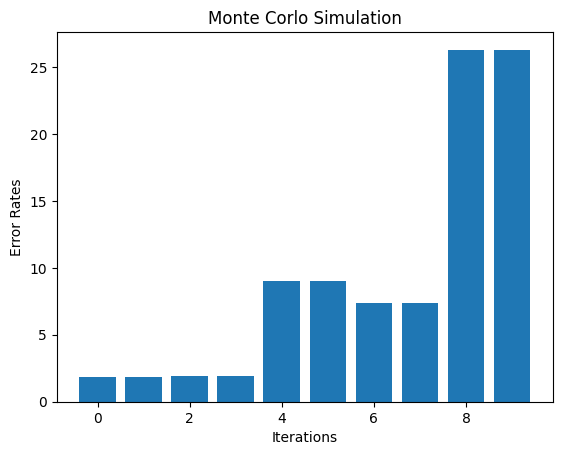

In [ ]:
error_rates,plt = get_error_plot(10)
print("Error Rates:",error_rate)
plt.show()

Task 3
In this task, you will be learning how to scrape website (extracting data from websites and
cleaning the scrapped Data) and data visualization using matplotlib.
a) Write a Python script to scrape the Top 250 TV-shows of all time from the IMDB
website. After scraping the data, save it to a MySQL database named ‘top-250-shows’ for
further analysis. You must also use the data from the obtained database to plot the following
graphs:
i. A bar graph representing Genre (on x-axis) to no. of TV-shows belonging to that genre
(on y-axis). (Note: A TV Show might have multiple genre)
ii. A line graph representing the frequency count of TV-shows having n episodes, n varies
from 1 to maximum no. of episodes present. Represent no. of episodes (on x-axis) and
frequency count (on y-axis).
b) Write a Python Program that allows user to filter the TV Shows based on:-
1. Genre
2. IMDB rating
3. No. of episode
For each filter take user-input to choose the criteria. The user must be prompted a range
(inclusive of both the limits) for IMDB rating and No. of episode and Genre must be a
string input consisting of genres separated by spaces. Print the TV-show in the descending
order based on the user-filtering.
>>./q3 b.py
Comdey Thriller Drama Documentary
8.5 9.5
10 20

## Task-3-a

In [1]:
import requests
from bs4 import BeautifulSoup as bs
from urllib.request import urlopen
from urllib.request import Request, urlopen
import json
import pandas as pd
import numpy as np
import warnings as warn
warn.filterwarnings('ignore')
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
def get_scrapped_data():
  imdb_url = 'https://www.imdb.com/chart/toptv/'
  req = Request(imdb_url, headers={"User-Agent": "Mozilla/5.0"})
  urlclient = urlopen(req)
  imdb_tv_shows = urlclient.read()
  imdb_html = bs(imdb_tv_shows, 'html.parser')
  tv_show_titles = imdb_html.find_all("h3" ,{"ipc-title__text"})
  tv_show_titles = [tv_show_titles[i] for i in range(len(tv_show_titles)) if str(tv_show_titles[i].get_text())[0].isdigit()]
  tv_show_titles = [show.get_text()[show.get_text().find('.')+2:] for show in tv_show_titles]
  tv_show_episodes = imdb_html.find_all("span" ,{"sc-be6f1408-8 fcCUPU cli-title-metadata-item"})
  tv_show_episodes = [tv_show_episodes[i] for i in range(len(tv_show_episodes)) if 'eps' in str(tv_show_episodes[i])]
  tv_show_episodes = [epi.get_text()[:epi.get_text().find('e')-1] for epi in tv_show_episodes]
  tv_show_ratings = imdb_html.find_all("span" ,{"class":"ipc-rating-star ipc-rating-star--base ipc-rating-star--imdb ratingGroup--imdb-rating"})
  for i in range(len(tv_show_ratings)):
    rating = str(tv_show_ratings[i].get_text())
    rating = rating[:3]
    tv_show_ratings[i] = rating
  imdb  = imdb_html.find('script',{'id':'__NEXT_DATA__'})
  json_data = json.loads(imdb.string)
  edges = json_data.get('props', {}).get('pageProps', {}).get('pageData', {}).get('chartTitles', {}).get('edges', [])
  tv_show_genres = list()
  for edge in edges:
    genres = list()
    for i in range(len(edge['node']['titleGenres']['genres'])):
      genres.append(edge['node']['titleGenres']['genres'][i]['genre']['text'])
    tv_show_genres.append(genres)
  data = list(zip(tv_show_titles, tv_show_episodes, tv_show_ratings, tv_show_genres))
  df = pd.DataFrame(data,columns=['title','episodes','rating','genres'])
  df['episodes'] = df['episodes'].astype(int)
  df['rating'] = df['rating'].astype(float)
  return df,tv_show_genres

In [3]:
def get_unique_genres(tv_show_genres):
  unique_genres = dict()
  for i in tv_show_genres:
    for j in i:
      if j not in unique_genres:
        unique_genres[j] = 1
      else:
        unique_genres[j] += 1
  unique_genres = dict(sorted(unique_genres.items()))
  return unique_genres

In [4]:
df,tv_show_genres = get_scrapped_data()

In [5]:
def plot_genres_tv_shows(unique_genres):
  plt.bar(unique_genres.keys(),unique_genres.values())
  plt.xlabel('Genres')
  plt.ylabel('No. TV Shows')
  plt.title('Genres vs No. TV Shows')
  plt.xticks(rotation=90)
  return plt

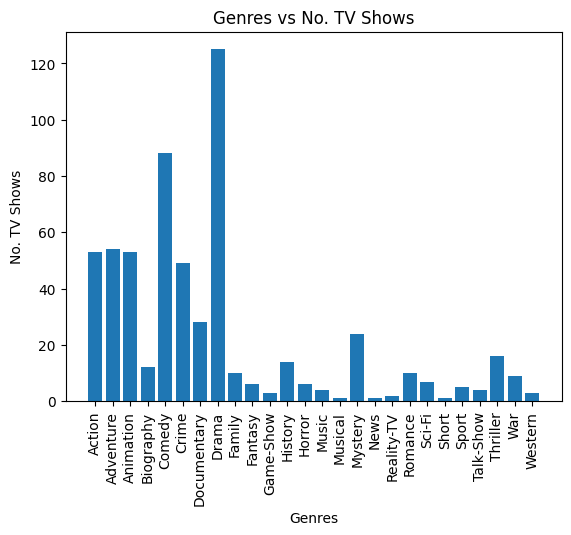

In [6]:
unique_genres = get_unique_genres(tv_show_genres)
plot_genres_tv_shows(unique_genres).show()

In [7]:
def get_unique_episodes(episodes):
  unique_episodes = dict()
  for i in list(episodes):
    if i not in unique_episodes:
      unique_episodes[i] = 1
    else:
      unique_episodes[i] += 1
  unique_episodes = dict(sorted(unique_episodes.items()))
  return unique_episodes

In [8]:
def plot_episodes_tv_shows(episodes,unique_episodes):
  max_episodes = max(episodes)
  min_episodes = min(episodes)
  x_values = np.linspace(min_episodes,max_episodes,len(unique_episodes))
  plt.plot(x_values,unique_episodes.values())
  plt.xlabel('No. Episodes')
  plt.ylabel('No. TV Shows')
  plt.title('No. Episodes vs No. TV Shows')
  return plt


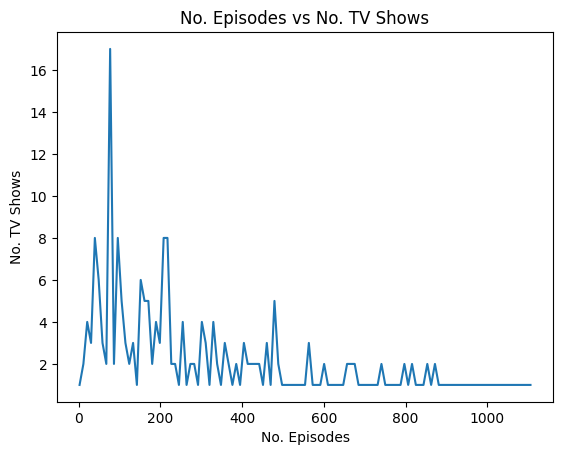

In [9]:
unique_episodes = get_unique_episodes(df.episodes)
plot_episodes_tv_shows(df.episodes,unique_episodes).show()

## Task-3-b

In [36]:
def get_filtered_tv_shows(genres,imdb_rating,episodes_range):
  genres = genres_list.split(' ')
  imdb_low, imdb_high = imdb_rating.split(' ')
  episodes_min,episodes_max = episodes_range.split(' ')
  imdb_low, imdb_high = float(imdb_low),float(imdb_high)
  episodes_min, episodes_max = int(episodes_min),int(episodes_max)
  df1 = pd.DataFrame(columns = df.columns)
  for i in range(len(df)):
    for j in genres:
      if j in df.loc[i].genres:
        row_df = pd.DataFrame([{'title':df.loc[i,'title'],'episodes':df.loc[i,'episodes'],'rating':df.loc[i,'rating'],'genres':df.loc[i,'genres']}])
        df1 = pd.concat([df1,row_df])
        # df1 = df1.append(df.loc[i])
        break
  df1 = df1.reset_index(drop=True)
  df2 = pd.DataFrame(columns = df.columns)
  for i in range(len(df1)):
    if (df1.loc[i,'rating']>=imdb_low and df1.loc[i,'rating']<=imdb_high) and (df1.loc[i,'episodes']>=episodes_min and df1.loc[i,'episodes']<=episodes_max):
        row_df = pd.DataFrame([{'title':df1.loc[i,'title'],'episodes':df1.loc[i,'episodes'],'rating':df1.loc[i,'rating'],'genres':df1.loc[i,'genres']}])
        df2 = pd.concat([df2,row_df])
        # df2 = df2.append(df1.loc[i])
  df2 = df2.reset_index(drop=True)
  df2 = df2.sort_values(by=['rating','episodes'],ascending=False).reset_index(drop=True)
  df2 = pd.DataFrame(df2.title)
  return df2

In [37]:
def get_wordcloud_top_tv_shows(shows):
  shows = list(shows.title)
  shows.reverse()
  weights = {show: rank+1 for rank,show in enumerate(shows)}
  wordcloud = WordCloud(width=300, height=300, background_color='black').generate_from_frequencies(weights)
  plt.figure(figsize=(5, 5))
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad=0)
  return plt

Enter Genres: Comdey Thriller Drama Documentary
Enter Imdb Range: 8.5 9.5
Enter Episodes Range: 10 20
                         title
0                 Planet Earth
1             Band of Brothers
2  Cosmos: A Spacetime Odyssey
3                       Cosmos
4                   Our Planet


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

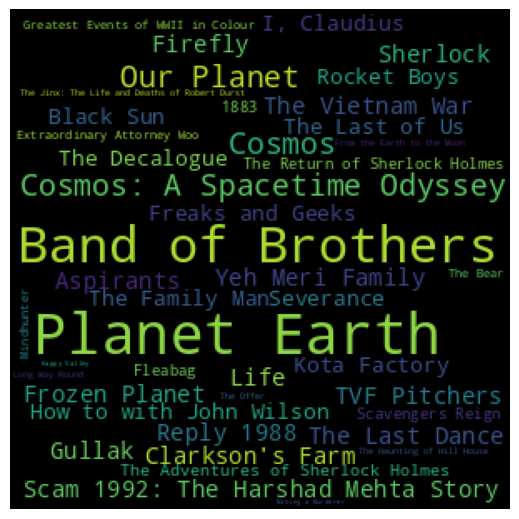

In [39]:
genres_list = input("Enter Genres: ")
imdb_rating = input("Enter Imdb Range: ")
episodes_range = input("Enter Episodes Range: ")
shows = get_filtered_tv_shows(genres_list,imdb_rating,episodes_range)
print(shows.head())
get_wordcloud_top_tv_shows(shows)